In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cleaned_data/tmg.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

In [3]:
df.shape

(2755, 6)

In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2755 entries, 2015-01-04 to 2026-04-30
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       2755 non-null   float64
 1   open        2755 non-null   float64
 2   high        2755 non-null   float64
 3   low         2755 non-null   float64
 4   vol         2291 non-null   float64
 5   change_pct  2755 non-null   float64
dtypes: float64(6)
memory usage: 150.7 KB


In [5]:
df.head()

,price,open,high,low,vol,change_pct
date,,,,,,
2015-01-04,9.89,9.95,9.97,9.79,NaN,0.30
2015-01-05,9.95,9.90,10.03,9.84,2.20,0.61
2015-01-06,9.71,9.81,9.82,9.52,1.07,-2.41
2015-01-08,9.90,9.90,10.00,9.85,1.44,1.96
2015-01-11,9.76,9.85,9.95,9.67,NaN,-1.41


In [6]:
df.tail()

,price,open,high,low,vol,change_pct
date,,,,,,
2026-04-26,93.00,93.81,94.28,93.00,1.65,-0.59
2026-04-27,94.00,93.45,95.37,93.01,4.47,1.08
2026-04-28,94.02,94.59,95.30,93.93,3.21,0.02
2026-04-29,94.70,94.28,95.50,93.93,4.72,0.72
2026-04-30,94.11,95.01,95.27,94.04,7.02,-0.62


In [7]:
#print null count
print(df.isnull().sum())

price           0
open            0
high            0
low             0
vol           464
change_pct      0
dtype: int64


In [8]:
#fill missing values in volume colummn with mean
df['vol'] = df['vol'].fillna(df['vol'].mean())

In [9]:
#Computing daily % return 
df['return'] = df['price'].pct_change() 

In [10]:
#Adding lag features
df['return_lag1'] = df['return'].shift(1)
df['return_lag2'] = df['return'].shift(2)

In [11]:
#Adding rolling features
df['ma_20']         = df['price'].rolling(20).mean()
df['volatility_20'] = df['return'].rolling(20).std()
df['ma_5']          = df['price'].rolling(5).mean()

In [12]:
df['dist_to_ma5'] = (df['price'] / df['ma_5']) - 1
df['dist_to_ma20'] = (df['price'] / df['ma_20']) - 1

In [13]:
# 1. Calculate the Fast (12-day) and Slow (26-day) Exponential Moving Averages (EMA)
ema_12 = df['price'].ewm(span=12, adjust=False).mean()
ema_26 = df['price'].ewm(span=26, adjust=False).mean()

# 2. Calculate the raw MACD line
df['macd'] = ema_12 - ema_26

# 3. Calculate the Signal Line (9-day EMA of the MACD)
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()

# 4. Calculate the MACD Histogram (The most useful feature for ML)
# This represents the distance between the MACD and its signal line
df['macd_hist'] = df['macd'] - df['macd_signal']

# What this does: A rising macd_hist means short-term momentum is accelerating upward.

In [14]:
# 1. Calculate the 20-day SMA (Middle Band) and 20-day Standard Deviation
window = 20
sma_20 = df['price'].rolling(window=window).mean()
std_20 = df['price'].rolling(window=window).std()

# 2. Calculate Upper and Lower Bands
upper_band = sma_20 + (std_20 * 2)
lower_band = sma_20 - (std_20 * 2)

# 3. Feature A: Bollinger %B (Where is price relative to the bands?)
# Value of 1.0 = price is touching upper band. Value of 0.0 = touching lower band.
df['bb_pb'] = (df['price'] - lower_band) / (upper_band - lower_band)

# 4. Feature B: Bollinger Bandwidth (How volatile is the market right now?)
# Useful for detecting "squeezes" before explosive moves.
df['bb_bandwidth'] = (upper_band - lower_band) / sma_20

In [15]:
#Adding RSI
delta = df['price'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
df['rsi'] = 100 - (100 / (1 + gain / loss))

In [16]:
threshold = 0.005

future_return = df['return'].shift(-1)

df['label'] = (future_return > threshold).astype(int)

In [17]:
#Adding rolling features adds NaN rows
df = df.dropna()

In [18]:
df.drop(columns=['price', 'ma_5', 'ma_20'], inplace=True)

In [19]:
# Note for modeling team: price, ma_5, ma_20 are in EGP price scale
# while return, rsi etc. are percentages. Please apply StandardScaler or MinMaxScaler before training.
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2735 entries, 2015-02-03 to 2026-04-30
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   open           2735 non-null   float64
 1   high           2735 non-null   float64
 2   low            2735 non-null   float64
 3   vol            2735 non-null   float64
 4   change_pct     2735 non-null   float64
 5   return         2735 non-null   float64
 6   return_lag1    2735 non-null   float64
 7   return_lag2    2735 non-null   float64
 8   volatility_20  2735 non-null   float64
 9   dist_to_ma5    2735 non-null   float64
 10  dist_to_ma20   2735 non-null   float64
 11  macd           2735 non-null   float64
 12  macd_signal    2735 non-null   float64
 13  macd_hist      2735 non-null   float64
 14  bb_pb          2735 non-null   float64
 15  bb_bandwidth   2735 non-null   float64
 16  rsi            2735 non-null   float64
 17  label          2735 non-null   int64  
dtypes

In [20]:
df.head()

,open,high,low,vol,change_pct,return,return_lag1,return_lag2,volatility_20,dist_to_ma5,dist_to_ma20,macd,macd_signal,macd_hist,bb_pb,bb_bandwidth,rsi,label
date,,,,,,,,,,,,,,,,,,
2015-02-03,11.75,12.10,11.75,6.86,3.01,0.030146,0.008688,0.001741,0.017685,0.029614,0.093336,0.454628,0.396214,0.058414,0.842369,0.272617,91.145833,0
2015-02-04,12.00,12.15,11.70,6.50,0.17,0.001672,0.030146,0.008688,0.017760,0.023057,0.085096,0.468407,0.410653,0.057755,0.816549,0.268823,90.810811,0
2015-02-05,11.84,11.93,11.60,5.50,-2.34,-0.023372,0.001672,0.030146,0.017686,-0.004425,0.050269,0.451530,0.418828,0.032701,0.704245,0.246122,75.543478,0
2015-02-08,11.71,11.91,11.39,2.97,-1.03,-0.010256,-0.023372,0.001672,0.018047,-0.015808,0.031718,0.423588,0.419780,0.003808,0.642208,0.223037,69.841270,0
2015-02-09,11.41,11.53,11.28,3.87,-1.99,-0.019862,-0.010256,-0.023372,0.018458,-0.031074,0.004114,0.378521,0.411528,-0.033007,0.522247,0.184915,55.307263,1


In [21]:
df.tail()

,open,high,low,vol,change_pct,return,return_lag1,return_lag2,volatility_20,dist_to_ma5,dist_to_ma20,macd,macd_signal,macd_hist,bb_pb,bb_bandwidth,rsi,label
date,,,,,,,,,,,,,,,,,,
2026-04-26,93.81,94.28,93.00,1.65,-0.59,-0.005879,0.003110,-0.008400,0.030154,-0.005050,0.099863,3.504618,2.261340,1.243278,0.802094,0.330569,85.192698,1
2026-04-27,93.45,95.37,93.01,4.47,1.08,0.010753,-0.005879,0.003110,0.029316,0.004574,0.100245,3.603050,2.529682,1.073367,0.805197,0.328461,85.797665,0
2026-04-28,94.59,95.30,93.93,3.21,0.02,0.000213,0.010753,-0.005879,0.028625,0.004852,0.088365,3.640703,2.751886,0.888817,0.780120,0.315453,92.947368,1
2026-04-29,94.28,95.50,93.93,4.72,0.72,0.007233,0.000213,0.010753,0.028326,0.009014,0.083574,3.682959,2.938101,0.744858,0.783265,0.295037,89.985052,0
2026-04-30,95.01,95.27,94.04,7.02,-0.62,-0.006230,0.007233,0.000213,0.026242,0.001532,0.067594,3.627029,3.075886,0.551143,0.736670,0.285604,85.130971,0


In [22]:
#return is the same as change_pct so we can drop change_pct
print((df['return'].round(2) == df['change_pct'].round(2)).value_counts())

False    2658
True       77
Name: count, dtype: int64


In [23]:
df.drop(columns=['open', 'high', 'low', 'change_pct'], inplace=True)

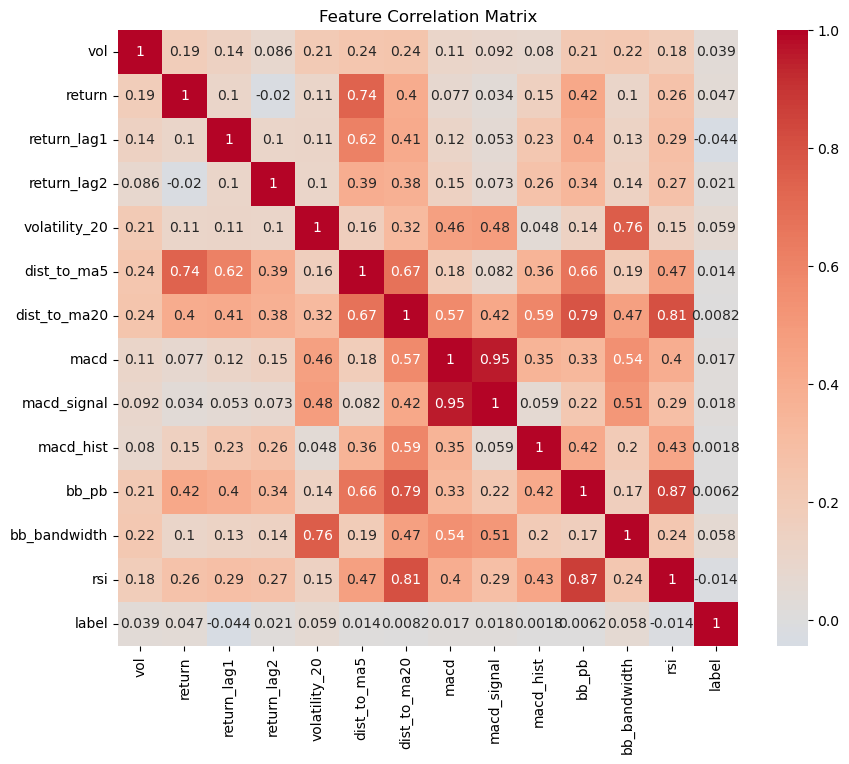

In [24]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)

plt.title('Feature Correlation Matrix')
plt.show()

In [25]:
#Dropping multicolinearity features
df.drop(columns=['dist_to_ma20', 'macd', 'macd_signal', 'volatility_20'], inplace=True)

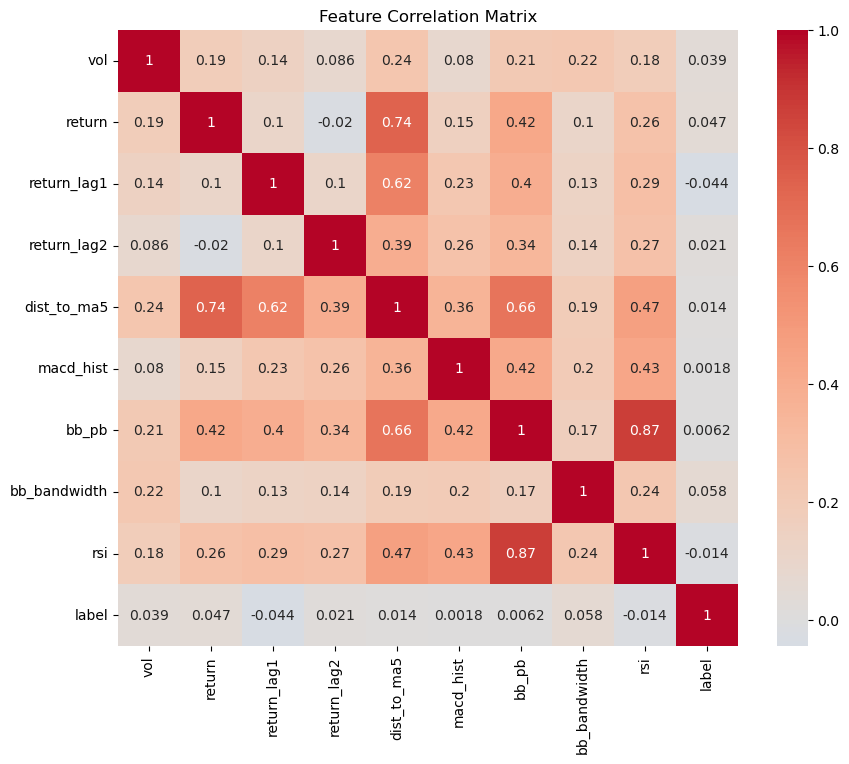

In [26]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)

plt.title('Feature Correlation Matrix')
plt.show()

In [27]:
asset_name = "TMG Index" 
sns.set_theme(style="darkgrid", palette="muted")

# We calculate Cumulative Return to visualize the "price" growth
cum_return = (1 + df['return']).cumprod()

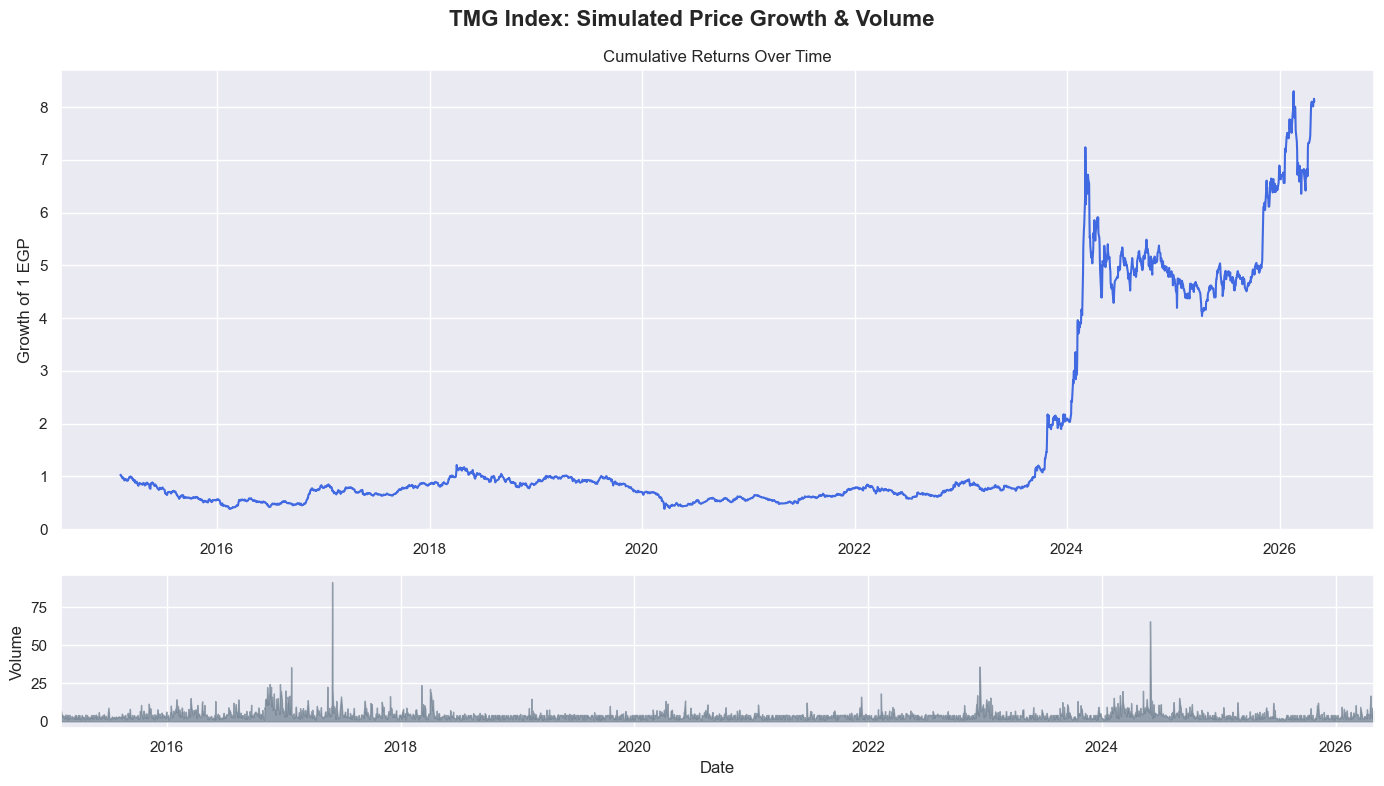

In [28]:
# ========================================================
# PLOT 1 - Macro Trend & Volume
# ========================================================
if 'vol' in df.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle(f"{asset_name}: Simulated Price Growth & Volume", fontsize=16, fontweight='bold')
    
    # Top Panel: Simulated Price (Cumulative Return)
    axes[0].plot(df.index, cum_return, color='royalblue', linewidth=1.5)
    axes[0].set_ylabel("Growth of 1 EGP")
    axes[0].set_title("Cumulative Returns Over Time")
    
    # Bottom Panel: Volume (FIXED: using fill_between instead of bar)
    axes[1].fill_between(df.index, df['vol'], color='slategray', alpha=0.7)
    axes[1].set_ylabel("Volume")
    axes[1].set_xlabel("Date")
    axes[1].margins(x=0) # Removes white space on the edges
    
else:
    fig, ax = plt.subplots(figsize=(14, 5))
    fig.suptitle(f"{asset_name}: Simulated Price Growth (No Volume Data)", fontsize=16, fontweight='bold')
    ax.plot(df.index, cum_return, color='royalblue', linewidth=1.5)
    ax.set_ylabel("Growth of 1 EGP")

plt.tight_layout()
plt.show()

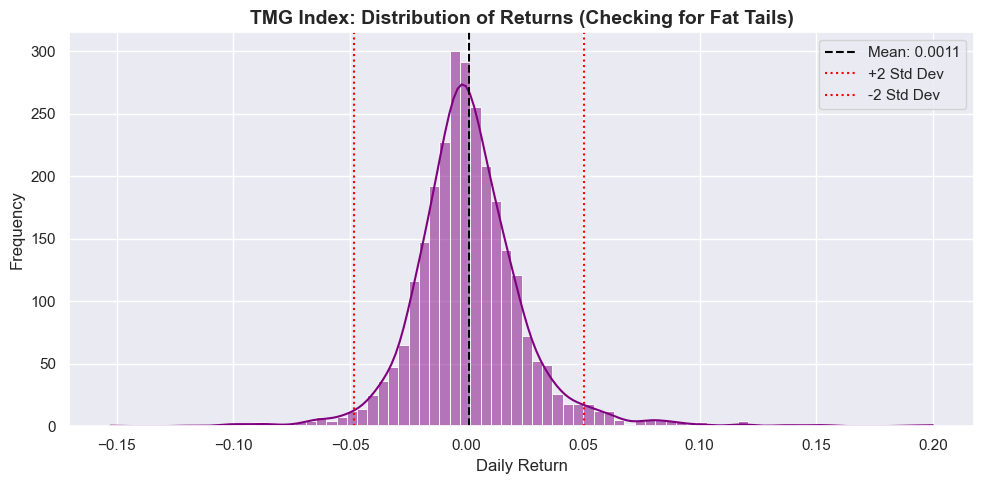

In [29]:
# ========================================================
# PLOT 2 - Distribution of Returns (Fat Tails)
# ========================================================
plt.figure(figsize=(10, 5))
sns.histplot(df['return'], kde=True, bins=80, color='purple')
plt.title(f"{asset_name}: Distribution of Returns (Checking for Fat Tails)", fontsize=14, fontweight='bold')
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

# Add statistical lines
mean_ret = df['return'].mean()
std_ret = df['return'].std()
plt.axvline(mean_ret, color='black', linestyle='--', label=f'Mean: {mean_ret:.4f}')
plt.axvline(mean_ret + (2*std_ret), color='red', linestyle=':', label='+2 Std Dev')
plt.axvline(mean_ret - (2*std_ret), color='red', linestyle=':', label='-2 Std Dev')

plt.legend()
plt.tight_layout()
plt.show()

C:\Users\moata\AppData\Local\Temp\ipykernel_26176\3776502680.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette=['#ff6b6b', '#1dd1a1'])


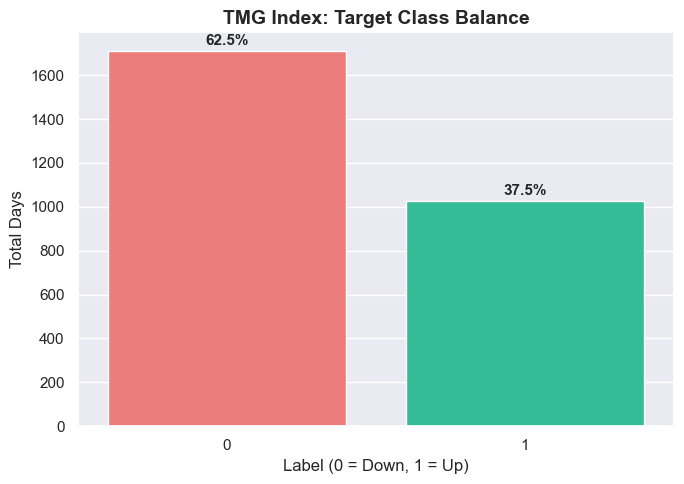

In [30]:
# ========================================================
# PLOT 3 - Target Class Balance
# ========================================================
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='label', palette=['#ff6b6b', '#1dd1a1'])
plt.title(f"{asset_name}: Target Class Balance", fontsize=14, fontweight='bold')
plt.xlabel("Label (0 = Down, 1 = Up)")
plt.ylabel("Total Days")

# Calculate and add percentages to the bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + (total * 0.01)
    ax.annotate(percentage, (x, y), ha='center', fontweight='bold', fontsize=11)
    
plt.tight_layout()
plt.show()

C:\Users\moata\AppData\Local\Temp\ipykernel_26176\2827658916.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
C:\Users\moata\AppData\Local\Temp\ipykernel_26176\2827658916.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
C:\Users\moata\AppData\Local\Temp\ipykernel_26176\2827658916.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], pal

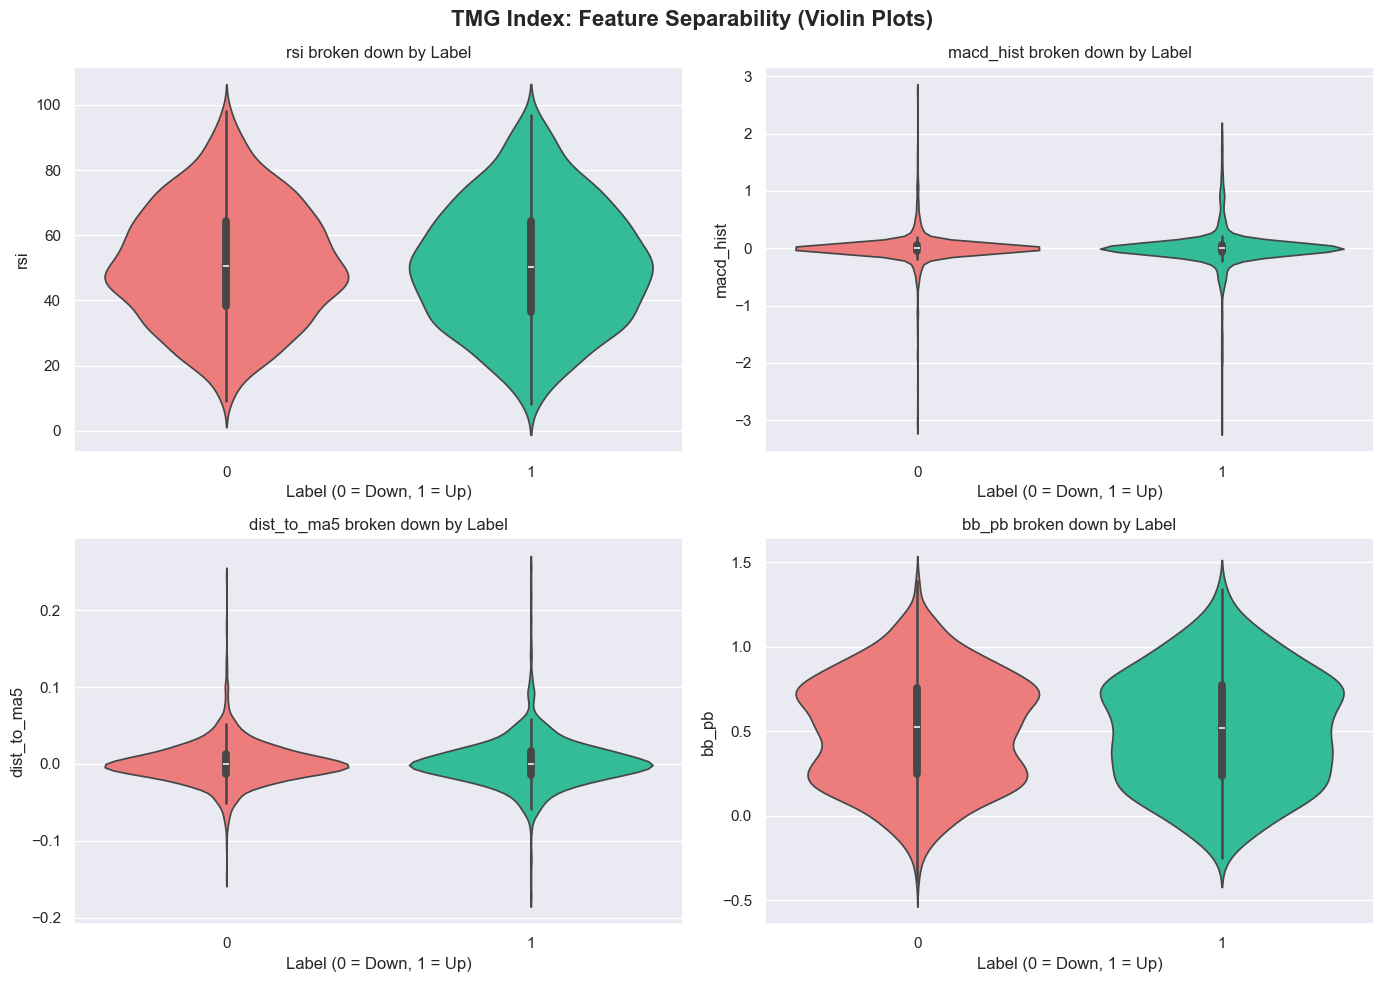

In [31]:
# ========================================================
# PLOT 4 - Feature Predictability (Violin Plots)
# ========================================================
# Selecting the 4 best ML features to plot
features = ['rsi', 'macd_hist', 'dist_to_ma5', 'bb_pb']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"{asset_name}: Feature Separability (Violin Plots)", fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
    axes[i].set_title(f"{feature} broken down by Label")
    axes[i].set_xlabel("Label (0 = Down, 1 = Up)")

plt.tight_layout()
plt.show()

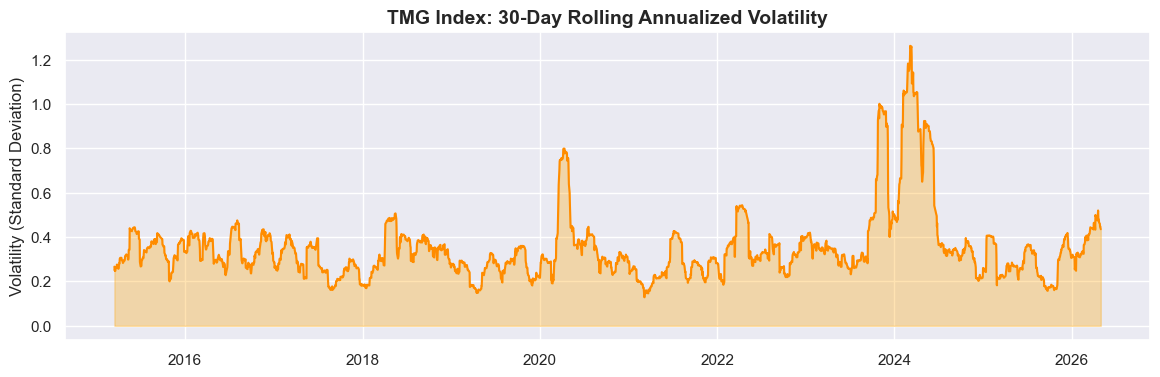

In [32]:
# CELL 7: Rolling Volatility (30-day)
df['rolling_volatility'] = df['return'].rolling(window=30).std() * np.sqrt(252) # Annualized

plt.figure(figsize=(14, 4))
plt.plot(df.index, df['rolling_volatility'], color='darkorange', linewidth=1.5)
plt.title(f"{asset_name}: 30-Day Rolling Annualized Volatility", fontsize=14, fontweight='bold')
plt.ylabel("Volatility (Standard Deviation)")
plt.fill_between(df.index, df['rolling_volatility'], alpha=0.3, color='orange')
plt.show()

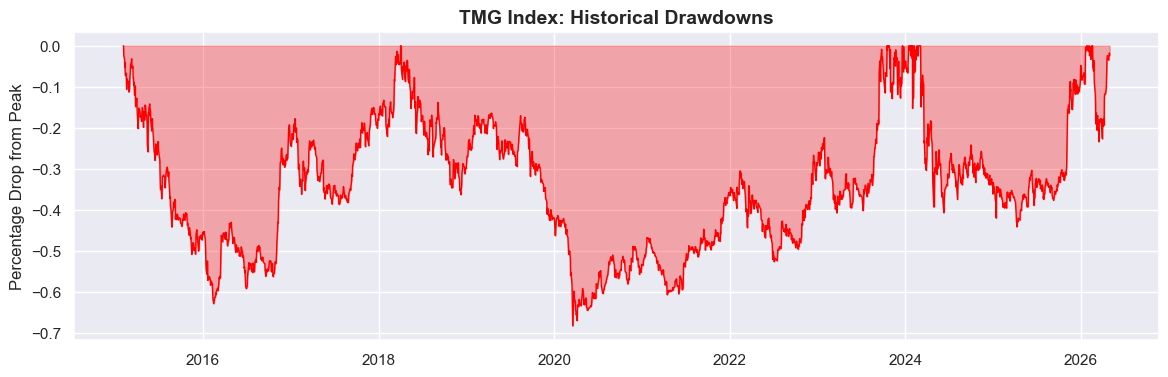

In [33]:
# CELL 8: Drawdown Chart
running_max = cum_return.cummax()
drawdown = (cum_return - running_max) / running_max

plt.figure(figsize=(14, 4))
plt.plot(df.index, drawdown, color='red', linewidth=1)
plt.fill_between(df.index, drawdown, 0, color='red', alpha=0.3)
plt.title(f"{asset_name}: Historical Drawdowns", fontsize=14, fontweight='bold')
plt.ylabel("Percentage Drop from Peak")
plt.show()

In [34]:
df.to_csv('final_data/final_tmg.csv')